/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


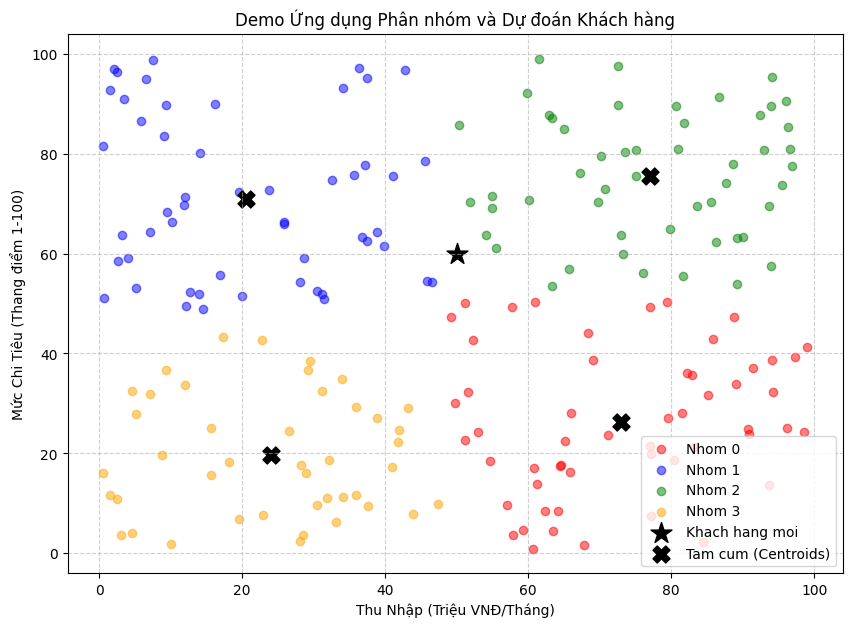

==> Kết quả dự đoán: Khách hàng mới được xếp vào: Nhóm 2


In [1]:
#bài4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# TẠO DỮ LIỆU GIẢ LẬP (Thu nhập và Mức chi tiêu)
np.random.seed(42)
customer_data = np.random.rand(200, 2) * 100
df = pd.DataFrame(customer_data, columns=['Thu_Nhap', 'Muc_Chi_Tieu'])

# --- BƯỚC 1: DEMO K-MEANS (PHÂN NHÓM) ---
# Giả sử ta muốn chia khách hàng thành 4 nhóm
kmeans_model = KMeans(n_clusters=4, n_init=10, random_state=42)
df['Nhom'] = kmeans_model.fit_predict(df[['Thu_Nhap', 'Muc_Chi_Tieu']])

# --- BƯỚC 2: DEMO K-NN (DỰ ĐOÁN CHO KHÁCH HÀNG MỚI) ---
# Giả sử có một khách hàng mới có Thu nhập = 50, Chi tiêu = 60
new_customer = np.array([[50, 60]])

# Sử dụng K-NN với k=5 và trọng số (distance) - Đáp ứng yêu cầu Bài 2
knn_model = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn_model.fit(df[['Thu_Nhap', 'Muc_Chi_Tieu']], df['Nhom'])

prediction = knn_model.predict(new_customer)

# --- BƯỚC 3: TRỰC QUAN HÓA KẾT QUẢ ---
plt.figure(figsize=(10, 7))

# Vẽ các nhóm khách hàng cũ
colors = ['red', 'blue', 'green', 'orange']
for i in range(4):
    subset = df[df['Nhom'] == i]
    plt.scatter(subset['Thu_Nhap'], subset['Muc_Chi_Tieu'], c=colors[i], label=f'Nhom {i}', alpha=0.5)

# Vẽ khách hàng mới
plt.scatter(new_customer[0,0], new_customer[0,1], c='black', marker='*', s=250, label='Khach hang moi')

# Vẽ tâm cụm của K-Means
centroids = kmeans_model.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=150, label='Tam cum (Centroids)')

plt.xlabel('Thu Nhập (Triệu VNĐ/Tháng)')
plt.ylabel('Mức Chi Tiêu (Thang điểm 1-100)')
plt.title('Demo Ứng dụng Phân nhóm và Dự đoán Khách hàng')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"==> Kết quả dự đoán: Khách hàng mới được xếp vào: Nhóm {prediction[0]}")

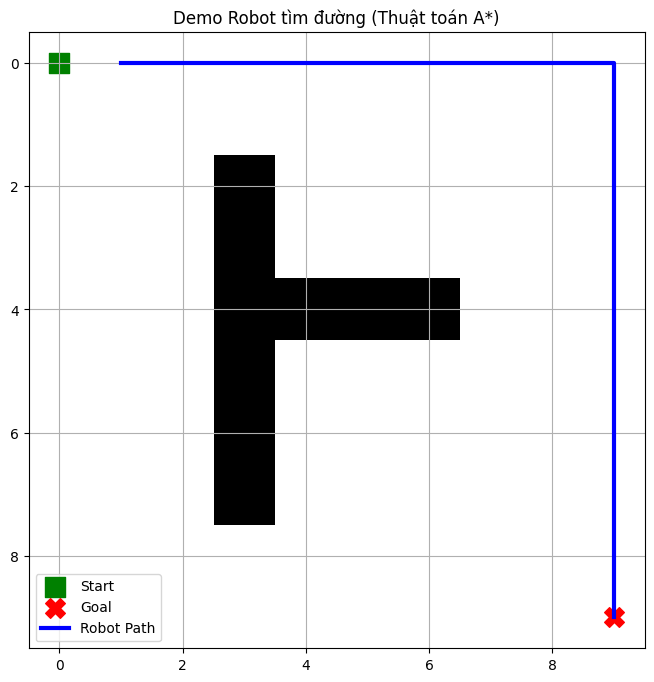

In [2]:
#bài5
import numpy as np
import matplotlib.pyplot as plt
import heapq

# 1. Định nghĩa bản đồ (0 là đường đi, 1 là vật cản)
maze = np.zeros((10, 10))
maze[2:8, 3] = 1 # Tạo một bức tường vật cản
maze[4, 4:7] = 1

start = (0, 0)
goal = (9, 9)

# 2. Hàm Heuristic (Khoảng cách Manhattan)
def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# 3. Thuật toán A*
def a_star(maze, start, goal):
    neighbors = [(0,1), (0,-1), (1,0), (-1,0)]
    close_set = set()
    came_from = {}
    gscore = {start: 0}
    fscore = {start: heuristic(start, goal)}
    oheap = []
    heapq.heappush(oheap, (fscore[start], start))

    while oheap:
        current = heapq.heappop(oheap)[1]

        if current == goal:
            data = []
            while current in came_from:
                data.append(current)
                current = came_from[current]
            return data[::-1]

        close_set.add(current)
        for i, j in neighbors:
            neighbor = current[0] + i, current[1] + j
            tentative_g_score = gscore[current] + 1

            if 0 <= neighbor[0] < maze.shape[0]:
                if 0 <= neighbor[1] < maze.shape[1]:
                    if maze[neighbor[0]][neighbor[1]] == 1:
                        continue
                else: continue
            else: continue

            if neighbor in close_set and tentative_g_score >= gscore.get(neighbor, 0):
                continue

            if tentative_g_score < gscore.get(neighbor, 0) or neighbor not in [i[1] for i in oheap]:
                came_from[neighbor] = current
                gscore[neighbor] = tentative_g_score
                fscore[neighbor] = gscore[neighbor] + heuristic(neighbor, goal)
                heapq.heappush(oheap, (fscore[neighbor], neighbor))
    return False

# 4. Chạy thuật toán và vẽ kết quả
path = a_star(maze, start, goal)

if path:
    path_x, path_y = zip(*path)
    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap='Greys')
    plt.scatter(start[1], start[0], color='green', s=200, label='Start', marker='s')
    plt.scatter(goal[1], goal[0], color='red', s=200, label='Goal', marker='X')
    plt.plot(path_y, path_x, color='blue', linewidth=3, label='Robot Path')
    plt.title("Demo Robot tìm đường (Thuật toán A*)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Không tìm thấy đường đi!")